In [7]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn import *
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import numpy as np
from numpy import interp
import re

# Generation of 50 shuffled train sets

In [ ]:
train = pd.read_csv(r'M:\ML_scripts\65_assay\colistin_train.csv')

shuffled_train_sets = []
num_dfs = 50

for i in range(num_dfs):

    df_shuffled = train.copy()
    df_shuffled['Class'] = np.random.permutation(df_shuffled['Class'])
    shuffled_train_sets.append(pd.DataFrame(df_shuffled))

output_folder = r'M:\ML_scripts\65_assay\y_randomisation\CM-65\train_sets'

for idx, df in enumerate(shuffled_train_sets):
    filename = f'rand_train_{idx+1}.csv'
    output_filepath = os.path.join(output_folder, filename)
    df.to_csv(output_filepath, index=False)
    print(f'Saved {filename} to {output_filepath}')

# Building of 50 random models

In [ ]:
def random_model_build():

    train_dir = r'M:\ML_scripts\65_assay\y_randomisation\CM-65\train_sets'
    data_dir = r'M:\ML_scripts\65_assay\y_randomisation\CM-65\train_sets'

    all_files = sorted([f for f in os.listdir(train_dir) if f.endswith('.csv')])
    train_files = [f for f in all_files if f.startswith('rand_train_')]

    for i, train_file in enumerate(train_files):

        train_file_path = os.path.join(data_dir, train_file)

        config = OptimizationConfig(        
    
            data = Dataset(
                input_column = 'Structure',
                response_column = 'Class',
                training_dataset_file=train_file_path,
                test_dataset_file=r'M:\ML_scripts\65_assay\colistin_test.csv',
                ),
            descriptors=[
                ECFP.new(),
                ECFP_counts.new(),
                MACCS_keys.new(),
                PhyschemDescriptors.new(),
                UnscaledPhyschemDescriptors.new(),
                CompositeDescriptor.new(
                    descriptors=[
                        ECFP_counts.new(),
                        UnscaledPhyschemDescriptors.new(),
                    ]
                ),
                CompositeDescriptor.new(
                    descriptors=[
                        MACCS_keys.new(),
                        UnscaledPhyschemDescriptors.new(),
                    ]
                ),
                CompositeDescriptor.new(
                    descriptors=[
                        ECFP.new(),
                        UnscaledPhyschemDescriptors.new(),
                    ]
                )
            ],
            algorithms=[
                RandomForestClassifier.new(),
                SVC.new(),
                LogisticRegression.new(),
                KNeighborsClassifier.new(),
            ],
            settings=OptimizationConfig.Settings(
                mode=ModelMode.CLASSIFICATION,
                cross_validation=10,
                cv_split_strategy=Stratified(),
                n_trials=200,
                n_startup_trials=50,
                direction=OptimizationDirection.MAXIMIZATION,
                random_seed=42,
                n_jobs=10,
            ),
        )

        study = optimize(config, study_name='study')

        build_best(buildconfig_best(study), f"M:/ML_scripts/65_assay/y_randomisation/CM-65/models/model_{i+1}.pkl")

    return

random_model_build()

# Plotting of AUROC curves

Avg AP (Random Models): 0.1017, Std AP: 0.0100
Mean TPR StdDev (Random Models): 0.0372


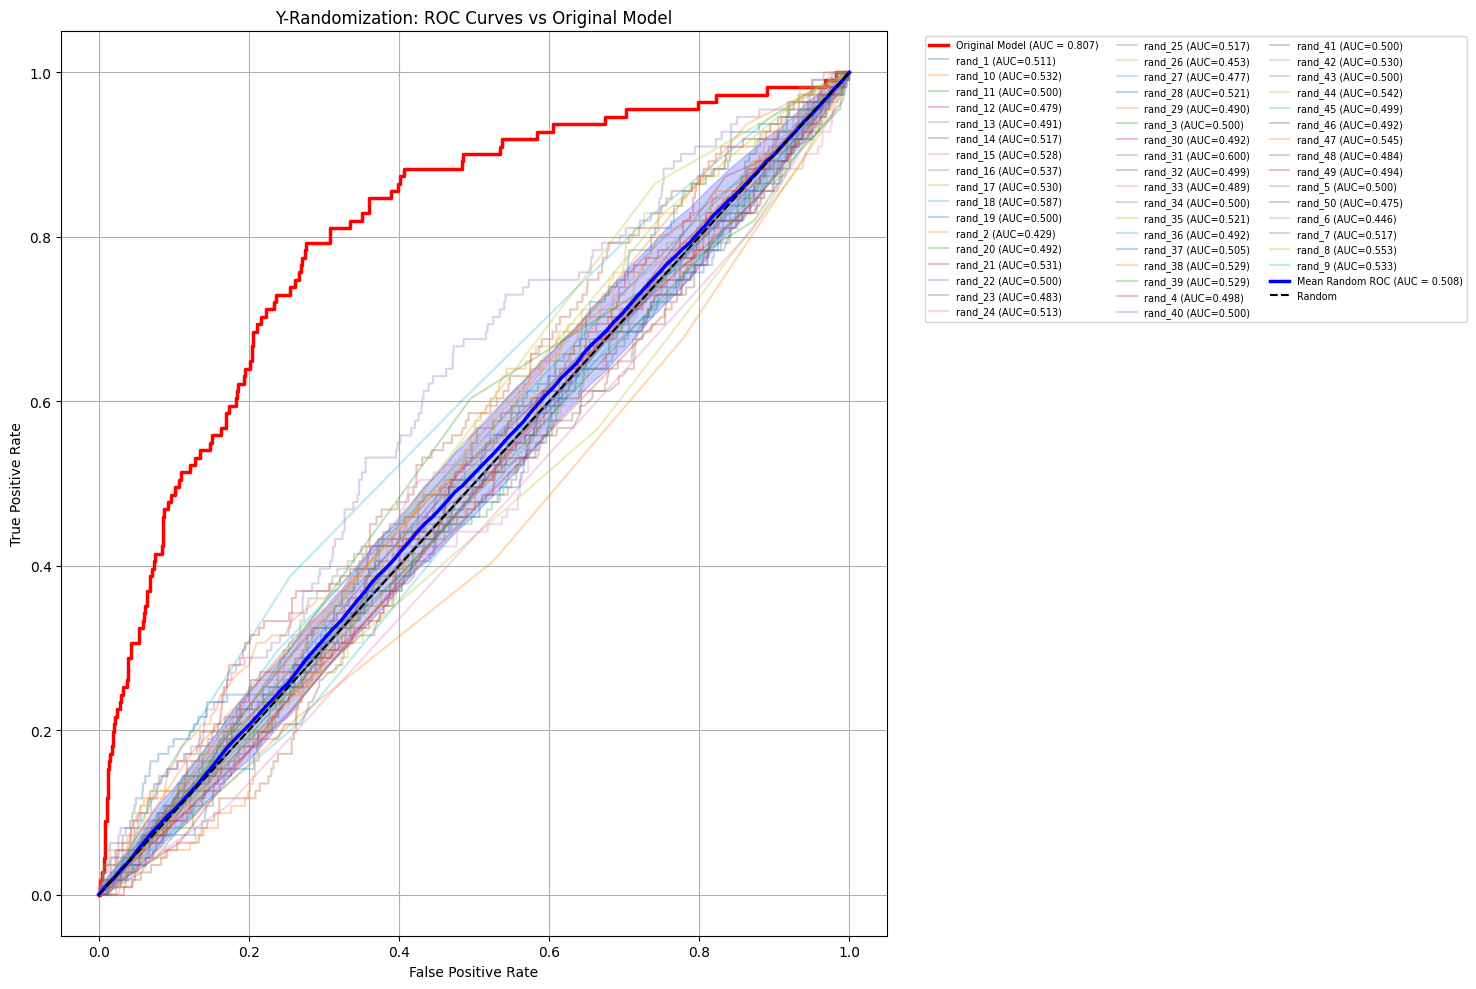

In [9]:
def plotYRand_roc(train_sets_folder, models_folder, test_file_path, original_model_path):

    plt.figure(figsize=(15, 10))
    mean_fpr = np.linspace(0, 1, 100)
    all_tprs = []
    ap_list = []
    processed = 0

    # Load test set once
    try:
        test_df = pd.read_csv(test_file_path)
        smiles = test_df["Structure"]
        true_labels = test_df["Class"]

    except Exception as e:
        print(f"[Error] Could not read test file: {e}")
        return

    # Plot ROC for original model (in red)
    try:
        with open(original_model_path, "rb") as f:
            original_model = pickle.load(f)

        orig_preds = original_model.predict_from_smiles(smiles)
        orig_fpr, orig_tpr, _ = roc_curve(true_labels, orig_preds)
        orig_auc = np.trapz(orig_tpr, orig_fpr)

        plt.plot(orig_fpr, orig_tpr, color='red', lw=2.5, label=f'Original Model (AUC = {orig_auc:.3f})')

    except Exception as e:
        print(f"[Error] Could not load original model: {e}")

    # Loop over randomized models
    train_files = sorted(f for f in os.listdir(train_sets_folder) if f.startswith("rand_train_") and f.endswith(".csv"))

    for train_file in train_files:
        match = re.match(r"rand_train_(\d+)\.csv", train_file)
        if not match:
            continue

        seed = match.group(1)
        model_path = os.path.join(models_folder, f"model_{seed}.pkl")

        try:
            with open(model_path, "rb") as f:
                model = pickle.load(f)

            preds = model.predict_from_smiles(smiles)
            fpr, tpr, _ = roc_curve(true_labels, preds)
            roc_auc = np.trapz(tpr, fpr)

            ap = average_precision_score(true_labels, preds)
            ap_list.append(ap)

            interp_tpr = interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)

            if processed < 50:
                plt.plot(fpr, tpr, alpha=0.3, label=f'rand_{seed} (AUC={roc_auc:.3f})')
            else:
                plt.plot(fpr, tpr, alpha=0.3)

            processed += 1

        except Exception as e:
            print(f"[Warning] Skipping seed_{seed}: {e}")

    # Mean + Std ROC curve for random models
    if all_tprs:
        all_tprs = np.array(all_tprs)
        mean_tpr = np.mean(all_tprs, axis=0)
        std_tpr = np.std(all_tprs, axis=0)
        mean_tpr[-1] = 1.0

        mean_auc = np.trapz(mean_tpr, mean_fpr)
        plt.plot(mean_fpr, mean_tpr, color='blue', lw=2.5, label=f'Mean Random ROC (AUC = {mean_auc:.3f})')

        tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
        tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
        plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Y-Randomization: ROC Curves vs Original Model')
    plt.grid(True)
    plt.legend(fontsize='x-small', loc='upper left', ncol=3, bbox_to_anchor=(1.04, 1))
    plt.tight_layout()

    print(f"Avg AP (Random Models): {np.mean(ap_list):.4f}, Std AP: {np.std(ap_list):.4f}")
    print(f"Mean TPR StdDev (Random Models): {np.mean(std_tpr):.4f}")

plotYRand_roc(

    original_model_path=r'M:\ML_scripts\MODEL DATA\colistin models_data\col_2.pkl',
    train_sets_folder=r'M:\ML_scripts\MODEL DATA\CM-1\train_sets',
    models_folder=r'M:\ML_scripts\MODEL DATA\CM-1\models',
    test_file_path=r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_testing_set.csv'
    
    )
